In [1]:
!pip install kornia
!pip install torchmetrics
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.4 MB/s eta 0:00:00


**The video is in this drive folder.**


https://drive.google.com/drive/folders/1AR5-u0r_7Z8RxO1qtJYXrEbxEWCgg5hd?usp=sharing

**1.Introduction**

**Title :          CV_ASSIGNMENT_3**

**Student Name   : Alihan Ertekin**

**Student Number : b2220765038**

In [49]:
# dataset path variables
# dataset_path points to the folder stored on the drive.
# data_path refers to the folder containing the input data.
dataset_path = '/content/drive/MyDrive/CV_B2220765038_ASSIGNMENT_3/data.zip'
shutil.copy(dataset_path, "/content/data.zip")
shutil.unpack_archive("/content/data.zip", "/content/data")
data_path = "/content/data/data/"

**2. Brief Explanation of Problem**

The core problem addressed in this project is identified as image colorization, where plausible color information is predicted for grayscale images to render them realistically. This is considered a challenging computer vision task because a single black-and-white pixel is often associated with many different colors in reality. To address this issue, Deep Convolutional Neural Networks (DCNNs) designed with an encoder-decoder architecture are utilized. In this framework, deep features are extracted from the input luminance channel by the encoder, while these features are used by the decoder to reconstruct the missing color channels. Furthermore, practical experience with base encoder-decoder structures and large-scale deep learning models is intended to be gained through this assignment. Finally, essential skills such as the preparation of a custom dataset, the implementation of model improvements, and the analysis of the impact of different architectural choices are expected to be learned.

**Implementation Note:**

The Kornia library is selected for this project due to its seamless compatibility with the PyTorch framework. It is preferred because image transformations, such as color space conversions, can be performed directly on the GPU (CUDA) without the need to move tensors back to the CPU. Consequently, computational efficiency is increased, and the training pipeline is kept fully differentiable. Furthermore, Kornia is recognized as a modern and stable tool for differentiable computer vision tasks.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
import glob
import os.path as osp
from torch.utils.data import Dataset, DataLoader,Subset
import kornia as K
from kornia.io import load_image,ImageLoadType
from kornia.core import Tensor
from kornia.geometry.transform import Resize
from kornia.color import RgbToLab,lab_to_rgb
from sklearn.model_selection import train_test_split
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.regression import MeanSquaredError
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


**3. Dataset Preparation**


In this section, a custom dataset class is initialized to manage the loading and preprocessing of image data. First, the file paths for both training and testing images are retrieved from the specified directories using the glob library. These paths are combined into a single list, and specific indices are generated to distinguish between the training and testing subsets. All images are loaded directly into the system memory (RAM) and stacked together to ensure rapid access during the training process.

A transformation pipeline is composed to prepare the images for the neural network. The images are resized to dimensions of 256x256 pixels using nearest neighbor interpolation, and the pixel values are converted to floating-point numbers. Subsequently, the color space is transformed from RGB to Lab to separate the lightness information from the color components. During the data retrieval process, the L channel is normalized by dividing by 100, and the ab channels are normalized by dividing by 128. Finally, the L channel is returned as the input for the model, while the ab channels are returned as the target for the prediction.

In [4]:
class MYColorizationDataset(Dataset):
  @torch.no_grad()
  def __init__(self,root_dir,train_folder_name,test_folder_name):
    super().__init__()
    # Dataset path
    self.root_dir = root_dir
    # accessing the dataset files
    train_img_paths = glob.glob(osp.join(self.root_dir,train_folder_name,"*.jpg"))
    test_img_paths = glob.glob(osp.join(self.root_dir,test_folder_name,"*.jpg"))
    self.paths = [*train_img_paths,*test_img_paths]

    # Getting the indicies of the train and test data
    self.train_idx = torch.arange(0,len(train_img_paths))
    self.test_idx = torch.arange(len(train_img_paths),len(train_img_paths)+len(test_img_paths))

    # loading image from path to ram
    self.imgs = torch.stack([load_image(img_p,ImageLoadType.UNCHANGED) for img_p in self.paths])

    # transforming image to suitable format
    self.transform = T.Compose([Resize((256,256), interpolation='nearest'),T.Lambda(lambda x: x.float() / 255.0),RgbToLab()])

  @torch.no_grad()
  def __len__(self):
    return self.imgs.shape[0]
  # returning L and ab chanell from given index
  @torch.no_grad()
  def __getitem__(self, index):
    img_lab = self.transform(self.imgs[index])
    return img_lab[0:1, :, :] / 100.0 , img_lab[1:,:,:] / 128.0




**4. Model Definitions**

In [64]:
'''SiLU is selected because a smoother non-linearity is provided,
   which allows for better gradient propagation
   and effective learning within the deep layers of the network.'''
class conv_filter(nn.Module):
  def __init__(self,input_dim,middle_dim,final_output_dim):
    super().__init__()
    self.conv_filter = nn.Sequential(
        #Convulation
        nn.Conv2d(input_dim,middle_dim,kernel_size=3,stride=1,padding=1),
        # Batch normalization to help stabilizing training and reducing vanishing/exploding gradients
        nn.BatchNorm2d(middle_dim),
        # Silu for activition function
        nn.SiLU(),
        nn.Conv2d(middle_dim,final_output_dim,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(final_output_dim),
        nn.SiLU()
    )


  def forward(self,x):
    return self.conv_filter(x)

''' Transposed convolution method is preferred over the traditional approach of upsampling followed by a standard convolution.
    The transposed convolution is selected because both the spatial expansion (upsampling) and
    the feature filtering are performed simultaneously in a single operation. By using this technique,
    the learnable parameters are applied directly during the upsampling process,
    and consistency is maintained with the SiLU activation and Batch Normalization used in the previous blocks.'''
class Transpose_conv_filter(nn.Module):
  def __init__(self,input_dim,final_output_dim):
    super().__init__()
    self.T_conv_filter = nn.Sequential(
        #Transpose Convulation
        nn.ConvTranspose2d(input_dim,final_output_dim,kernel_size=5,stride=2,output_padding=1,padding=2),
        nn.BatchNorm2d(final_output_dim),
        nn.SiLU()
    )
  def forward(self,x):
    return self.T_conv_filter(x)

'''Global Feature Extractor
   To capture the high-level semantic context of the input image, a global feature extractor module is implemented.
   When a pre-trained backbone is utilized, EfficientNet B0 is selected as the primary architecture.
   This specific model is chosen because a highly efficient performance is offered with a significantly lower parameter count compared to heavier architectures.
   Consequently, computational complexity is reduced, and the training process is accelerated while sufficient representation power is maintained.
   Since pre-trained networks like EfficientNet or VGG are originally designed for RGB images, a 3-channel input is expected;
   therefore, the input data is handled to satisfy this requirement. In cases where the pre-trained weights are not used,
   a custom sequential network is constructed. Within this custom design, Adaptive Max Pooling is employed between the convolutional layers.
   This pooling strategy is preferred because the most dominant features are emphasized, which allows the general context and
   the overall structure of the image to be understood more effectively during the feature extraction process.'''
class Global_feature_extractor(nn.Module):
  def __init__(self,global_f=None):
    super().__init__()
    if global_f is not None:
      self.gf = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    else:
      self.gf = nn.Sequential(conv_filter(input_dim=3,middle_dim=32,final_output_dim=64),

                              nn.AdaptiveMaxPool2d((128,128)),
                              conv_filter(input_dim=64,middle_dim=64,final_output_dim=128),
                              nn.AdaptiveMaxPool2d((64,64)),
                              conv_filter(input_dim=128,middle_dim=128,final_output_dim=256),
                              nn.AdaptiveMaxPool2d((32,32)),
                              conv_filter(input_dim=256,middle_dim=256,final_output_dim=512),
                              nn.AdaptiveAvgPool2d((1,1)),
                              nn.Flatten(),
                              nn.Linear(in_features=512,out_features=1000)
                              )
  def forward(self,x):
    return self.gf(x)


''' Baseline Model Architecture
    The Baseline_Model class is implemented to strictly replicate
    the base encoder-decoder architecture illustrated in the assignment instructions.
    In the encoder section, the input image is processed
    through sequential layers where AdaptiveAvgPool2d is applied immediately after the convolutional filters.
    This pooling mechanism is specifically chosen to downsample the feature maps.
    By reducing the spatial dimensions, the receptive field of the subsequent layers is effectively increased.
    This design allows the network to capture broader spatial patterns and the structural essence of the image,
    rather than focusing solely on fine pixel-level details.
    Following the feature extraction, the local features from the encoder are concatenated
    with the vector obtained from the global feature extractor. Finally, this fused representation is passed through the decoder,
    where the spatial resolution is progressively restored to generate the final 'a' and 'b' color channels. '''

class Baseline_Model(nn.Module):
  def __init__(self,global_f=None,freeze=False):
    super().__init__()
    #ENCODER
    self.low_layer1 = nn.Sequential(conv_filter(input_dim=1,middle_dim=64,final_output_dim=128),
                                    nn.AdaptiveAvgPool2d((128,128))
                                    )
    self.low_layer2 = nn.Sequential(conv_filter(input_dim=128,middle_dim=128,final_output_dim=256),
                                    nn.AdaptiveAvgPool2d((64,64)))
    self.low_layer3 = nn.Sequential(conv_filter(input_dim=256,middle_dim=256,final_output_dim=512),
                                    nn.AdaptiveAvgPool2d((32,32)))
    self.mid_layer = conv_filter(input_dim=512,middle_dim=256,final_output_dim=256)
    self.Encoder = nn.Sequential(self.low_layer1,self.low_layer2,self.low_layer3,self.mid_layer)


    #GLOBAL
    self.gf = Global_feature_extractor(global_f=global_f)
    self.gf.requires_grad_(not freeze)

    #DECODER
    self.before_decoder_layer = conv_filter(input_dim=1256,middle_dim=256,final_output_dim=128)
    self.decoder_layer1 = nn.Sequential(Transpose_conv_filter(input_dim=128,final_output_dim=64))
    self.decoder_layer2 = nn.Sequential(Transpose_conv_filter(input_dim=64,final_output_dim=32))
    self.decoder_layer3 = nn.Sequential(nn.ConvTranspose2d(32,2,kernel_size=5,stride=2,output_padding=1,padding=2))
    self.Decoder = nn.Sequential(self.before_decoder_layer,self.decoder_layer1,self.decoder_layer2,self.decoder_layer3)

  def forward(self,x):
    out = self.Encoder(x)

    out_global = self.gf(x.repeat(1, 3, 1, 1))
    out_global = out_global.unsqueeze(2).unsqueeze(3)
    out = torch.cat([out, out_global.repeat(1,1,32,32)], dim=1)
    return self.Decoder(out)

''' Improved Model Architecture (U-Net Based)
    In accordance with the requirement to enhance the model architecture,
    a U-Net based design is implemented as an improvement over the baseline.
    This approach is specifically adopted
    because potential issues regarding vanishing or exploding gradients were suspected during the evaluation of the initial model.
    To address these stability concerns and to facilitate a more effective flow of gradients,
    direct skip connections are introduced between the encoder and the decoder layers.
    By concatenating the feature maps from the encoding path directly with the corresponding layers in the decoding path,
    the loss of high-resolution spatial information is prevented.'''
class U_net_based_model(nn.Module):
  def __init__(self,global_f=None,freeze=False):
    super().__init__()
    #ENCODER
    self.low_layer1 = nn.Sequential(conv_filter(input_dim=1,middle_dim=64,final_output_dim=128),
                                    nn.AdaptiveAvgPool2d((128,128))
                                    )
    self.low_layer2 = nn.Sequential(conv_filter(input_dim=128,middle_dim=128,final_output_dim=256),
                                    nn.AdaptiveAvgPool2d((64,64)))
    self.low_layer3 = nn.Sequential(conv_filter(input_dim=256,middle_dim=256,final_output_dim=512),
                                    nn.AdaptiveAvgPool2d((32,32)))
    self.mid_layer = conv_filter(input_dim=512,middle_dim=256,final_output_dim=256)




    #GLOBAL
    self.gf = Global_feature_extractor(global_f=global_f)
    self.gf.requires_grad_(not freeze)

    #DECODER
    self.before_decoder_layer = conv_filter(input_dim=1256,middle_dim=256,final_output_dim=256)
    self.decoder_layer1 = nn.Sequential(conv_filter(input_dim=768,middle_dim=256,final_output_dim=128),
                                        Transpose_conv_filter(input_dim=128,final_output_dim=64)
                                        )
    #concat decoder1 output to encoder layer 2 output
    self.decoder_layer2 = nn.Sequential(conv_filter(input_dim=320,middle_dim=64,final_output_dim=64),
                                        Transpose_conv_filter(input_dim=64,final_output_dim=32))
    # concat decoder2 output to encoder layer 1 output
    self.decoder_layer3 = nn.Sequential(conv_filter(input_dim=160,middle_dim=32,final_output_dim=32),
                                        nn.ConvTranspose2d(32,2,kernel_size=5,stride=2,output_padding=1,padding=2))

  def forward(self,x):
    x1 = self.low_layer1(x)
    x2 = self.low_layer2(x1)
    x3 = self.low_layer3(x2)
    x4 = self.mid_layer(x3)
    out_global = self.gf(x.repeat(1, 3, 1, 1))
    out_global = out_global.unsqueeze(2).unsqueeze(3)
    out = torch.cat([x4, out_global.repeat(1,1,32,32)], dim=1)
    x4 = self.before_decoder_layer(out)
    x4 = self.decoder_layer1(torch.cat([x3,x4], dim=1))
    x4 = self.decoder_layer2(torch.cat([x2,x4], dim=1))
    x4 = self.decoder_layer3(torch.cat([x1,x4], dim=1))
    return x4









In [46]:
''' Perceptual Loss Implementation
    To enhance the visual quality and texture realism of the generated images,
    a perceptual loss module is implemented. As suggested in the assignment guidelines,
    a pre-trained VGG16 network is utilized to compute feature-based differences.
    The model is initialized with ImageNet weights, and its parameters are frozen
    to ensure stability during the training of the main colorization network.
    To focus solely on feature extraction, the classifier and average pooling layers are replaced with identity mappings.
    Since the colorization model outputs images in the Lab color space,
    a conversion to RGB is performed before feature extraction. Furthermore,
    the RGB images are normalized using the standard mean and standard deviation values of the ImageNet dataset
    to ensure compatibility with the pre-trained VGG network.
    Features are extracted from both the predicted and target images, and the Mean Squared Error (MSE) is calculated between these high-level representations.
    Finally, the resulting loss is scaled by a specific lambda factor to balance its impact relative to other loss components.'''
class Perceptual_loss():
  @torch.no_grad()
  def __init__(self,device,lda=0.1,clr_only = False):
    # to use convert_lab_to_rgb it self
    if not clr_only:
      #pretrained vgg model
      self.model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).to(device)
      # freezing vgg model to better loss and stable loss
      self.model.requires_grad_(False)
      # to use just features of the vgg
      self.model.classifier = nn.Identity()
      self.model.avgpool = nn.Identity()
    # loss function
    self.loss = nn.MSELoss()
    # scale factor for lab2rgb convertion
    self.scale = torch.tensor([100.0,128.0,128.0]).view(1,3,1,1).to(device)
    # lambda for reducing the effect of big loss.
    self.lda =lda

  def convert_lab_to_rgb(self,image):
    lab = image * self.scale
    rgb = lab_to_rgb(lab)
    return rgb

  def get_feature(self,pred,target):
    pred_i = self.convert_lab_to_rgb(pred)
    target_i = self.convert_lab_to_rgb(target)
    # normalizing image to image net std and mean to get better loss calc
    pred_i = T.functional.normalize(pred_i,[0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    target_i = T.functional.normalize(target_i,[0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    return self.model(pred_i), self.model(target_i)

  def calculate_loss(self,pred,target):
    pred_f ,target_f = self.get_feature(pred,target)
    return self.lda*self.loss(pred_f,target_f)



In [32]:

class Trainer():
  def __init__(self,device,model,optimizer,data,loss="L1",save_path = "/content/best_model.pth"):
    self.device =device
    self.model = model.to(device)
    train , val =train_test_split(data.train_idx,test_size=0.2,random_state=42,shuffle=True)
    self.train_data = Subset(data,train)
    self.validation_data = Subset(data,val)
    self.test_data = Subset(data,data.test_idx)
    self.optimizer = optimizer
    self.best_psnr = -float("inf")
    self.psnr_metric = PeakSignalNoiseRatio(data_range=2.0).to(device)
    self.ssim_metric = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)
    self.mse_metric = MeanSquaredError().to(device)
    self.save_path = save_path
    self.scale = torch.tensor([100.0,128.0,128.0]).view(1,3,1,1).to(device)
    if loss == "L1":
      self.loss = nn.L1Loss()
    elif loss == "perceptual":
      perc = Perceptual_loss(device=self.device)
      perc_loss = perc.calculate_loss
      self.loss = lambda x,y: perc_loss(x,y)
    elif loss == "both":
      L1 = nn.L1Loss()
      perc = Perceptual_loss(device=self.device)
      perc_loss = perc.calculate_loss
      self.loss = lambda x,y: L1(x,y) + perc_loss(x,y)
    else:
      assert 1 == 1
      assert 1 != 1

  def train_one_epoch(self,train_set_Batches):
    self.model.train()
    counter = 0
    total_loss = 0


    for x_set ,y_labels in train_set_Batches:
        x_set = x_set.to(device)
        y_labels = y_labels.to(device)
        counter += 1
        self.optimizer.zero_grad()
        logits = self.model(x_set)
        logits = torch.cat([x_set,logits],dim=1)
        y_labels = torch.cat([x_set,y_labels],dim=1)
        loss = self.loss(logits,y_labels)

        loss.backward()
        self.optimizer.step()

        total_loss += loss.item()
    return total_loss/counter

  @torch.no_grad()
  def test_validate(self,data_set_Batches):
    self.model.eval()
    counter = 0
    total_loss = 0
    self.psnr_metric.reset()
    self.ssim_metric.reset()
    self.mse_metric.reset()

    for x_set ,y_labels in data_set_Batches:
        x_set = x_set.to(device)
        y_labels = y_labels.to(device)
        counter += 1
        logits = self.model(x_set)
        logits = torch.cat([x_set,logits],dim=1)
        y_labels = torch.cat([x_set,y_labels],dim=1)
        loss = self.loss(logits,y_labels)
        logits = self.convert_lab_to_rgb(logits)
        y_labels = self.convert_lab_to_rgb(y_labels)
        self.psnr_metric.update(logits, y_labels)
        self.ssim_metric.update(logits, y_labels)
        self.mse_metric.update(logits, y_labels)
        total_loss += loss.item()
    final_psnr = self.psnr_metric.compute().item()
    final_ssim = self.ssim_metric.compute().item()
    final_mse = self.mse_metric.compute().item()
    return total_loss/counter,final_psnr,final_ssim,final_mse
  @torch.no_grad()
  def test(self):
    test_set_Batches = DataLoader(self.test_data, batch_size=16,shuffle=True,persistent_workers=False)
    return self.test_validate(test_set_Batches)
  @torch.no_grad()
  def convert_lab_to_rgb(self,image):
    lab = image * self.scale
    rgb = lab_to_rgb(lab)
    return rgb

  def fit(self,epoch_num):
    train_losses = []
    val_losses = []
    train_set_Batches = DataLoader(self.train_data, batch_size=16,shuffle=True,persistent_workers=False)
    data_set_Batches = DataLoader(self.validation_data, batch_size=16,shuffle=True,persistent_workers=False)
    for epoch in range(epoch_num):
      train_loss = self.train_one_epoch(train_set_Batches)
      val_loss , val_psnr, val_ssim ,val_mse = self.test_validate(data_set_Batches)
      print(f"\nEpoch {epoch+1}/{epoch_num} | LOSS -> Train Loss: {train_loss:.4f} : Val Loss: {val_loss:.4f} | Metrics -> MSE: {val_mse:.4f} : PSNR: {val_psnr:.2f} : SSIM: {val_ssim:.4f}")
      if val_psnr > self.best_psnr:
        print("model is saving")
        self.best_psnr = val_psnr
        torch.save(self.model.state_dict(),self.save_path)
      train_losses.append(train_loss)
      val_losses.append(val_loss)
    return train_losses,val_losses


In [8]:
def run_model_on_three_samples(model, dataset, indices, device):
    model.eval()
    model.to(device)
    preds = []
    with torch.no_grad():
        for idx in indices:
            L, ab = dataset.__getitem__(idx)
            L_in = L.unsqueeze(0).to(device)
            ab_pred = model(L_in)
            LAB_pred = torch.cat([L_in, ab_pred], dim=1)
            RGB_pred = tr.convert_lab_to_rgb(LAB_pred).squeeze(0)
            preds.append(RGB_pred.permute(1,2,0).cpu().numpy())
    return np.array(preds)

In [55]:
def visualize_predictions(dataset, indices, pred_lists, model_names, device='cpu'):

    n_models = len(pred_lists)
    n_samples = len(indices)
    pc = Perceptual_loss(device=device,clr_only=True)
    for sample_i, idx in enumerate(indices):
        L, ab = dataset[idx]
        L_img = L.permute(1, 2, 0).cpu().numpy()
        LAB_gt = torch.cat([L, ab], dim=0).unsqueeze(0).to(device)
        RGB_gt = pc.convert_lab_to_rgb(LAB_gt).squeeze(0)
        RGB_gt = RGB_gt.permute(1, 2, 0).cpu().numpy()

        plt.figure(figsize=(4 * (n_models + 2), 4))

        plt.subplot(1, n_models + 2, 1)
        plt.imshow(L_img.squeeze(), cmap='gray')
        plt.title("Input")
        plt.axis('off')

        for mi, preds in enumerate(pred_lists):
            rgb = preds[sample_i]
            plt.subplot(1, n_models + 2, mi + 2)
            plt.imshow(rgb)
            plt.title(model_names[mi])
            plt.axis('off')

        plt.subplot(1, n_models + 2, n_models + 2)
        plt.imshow(RGB_gt)
        plt.title("Ground Truth")
        plt.axis('off')

        plt.show()


In [10]:
def show_Lab_and_RGB_fancy(dataset, indices, device):
    n = len(indices)
    fig, axes = plt.subplots(n, 4, figsize=(18, 4*n))
    pc = Perceptual_loss(device=device,clr_only=True)
    if n == 1:
        axes = np.expand_dims(axes, 0)

    for i, idx in enumerate(indices):
        L, ab = dataset[idx]
        LAB = torch.cat([L, ab], dim=0).unsqueeze(0).to(device)
        RGB = pc.convert_lab_to_rgb(LAB).squeeze(0).permute(1, 2, 0).cpu().numpy()

        L_img  = L.squeeze(0).cpu().numpy()
        a_img  = ab[0].cpu().numpy()
        b_img  = ab[1].cpu().numpy()

        a_norm = (a_img + 128) / 255
        b_norm = (b_img + 128) / 255

        axes[i, 0].imshow(RGB)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(L_img, cmap='gray')
        axes[i, 1].set_title("L* Channel")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(a_norm, cmap='RdYlGn')
        axes[i, 2].set_title("a* Channel (Red-Green)")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(b_norm, cmap='coolwarm')
        axes[i, 3].set_title("b* Channel (Blue-Yellow)")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
def plot_losses_and_best_table(model_names, train_losses_list, val_losses_list,test_loss, psnrs, mses, ssims, loss_label='Loss'):
  num_models = len(model_names)
  fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))
  if num_models == 1:
        axes = [axes]
  plt.figure(figsize=(10, 6))
  for ax,name, train, val in zip(axes,model_names, train_losses_list, val_losses_list):
      train = np.asarray(train)
      val = np.asarray(val)
      epochs = np.arange(1, len(train) + 1)

      ax.plot(epochs, val, label='val')
      ax.plot(epochs, train, linestyle='--', label='train')

      ax.set_title(name)
      ax.set_xlabel("Epoch")
      ax.set_ylabel(loss_label)
      ax.set_xticks(epochs)
      ax.grid(True)
      ax.legend()

  plt.tight_layout()
  plt.show()

  rows = []
  for name, psnrs, mses, ssims, loss in zip(model_names, psnrs, mses, ssims, test_loss):
      rows.append({'model': name,
                    'psnr': float(psnrs),
                    'mse': float(mses),
                    'ssim': float(ssims),
                    'val_loss_at_best': float(loss)})

  df = pd.DataFrame(rows).set_index('model')
  return df


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
data = MYColorizationDataset(data_path,"train_color","test_color")


**Example image required for the dataset section**

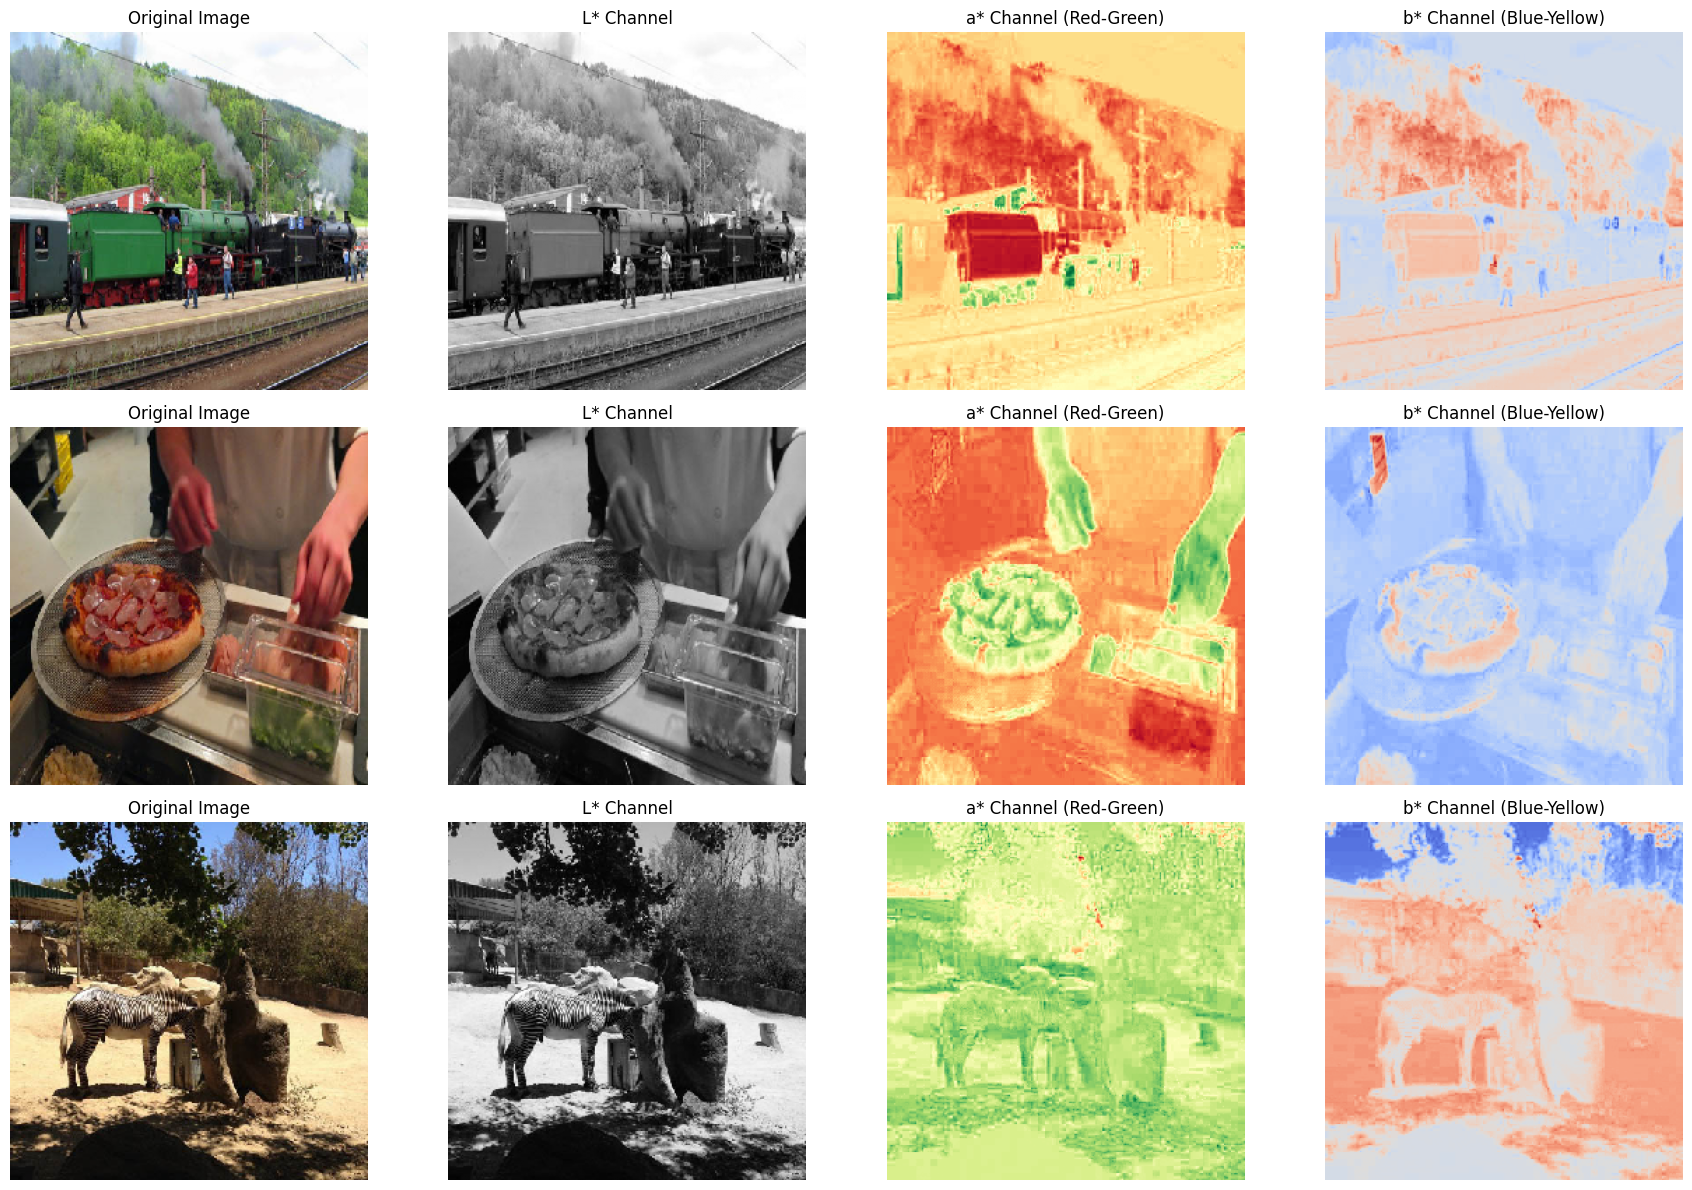

In [13]:
show_Lab_and_RGB_fancy(data,[5001,5002,5003], device)

In [14]:
model = Baseline_Model()
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="L1",
        save_path ="/content/L1_base.pth"
        )
train_losses_L1,val_losses_L1 = tr.fit(10)
model.load_state_dict(torch.load("/content/L1_base.pth", map_location=device))
test_loss_L1,test_mse_L1,test_psnr_L1,test_ssim_L1 = tr.test()
L1_preds = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/10 | LOSS -> Train Loss: 0.0626 : Val Loss: 0.0504 | Metrics -> MSE: 0.0080 : PSNR: 27.00 : SSIM: 0.9279
model is saving

Epoch 2/10 | LOSS -> Train Loss: 0.0498 : Val Loss: 0.0476 | Metrics -> MSE: 0.0073 : PSNR: 27.41 : SSIM: 0.9370
model is saving

Epoch 3/10 | LOSS -> Train Loss: 0.0489 : Val Loss: 0.0480 | Metrics -> MSE: 0.0074 : PSNR: 27.33 : SSIM: 0.9362

Epoch 4/10 | LOSS -> Train Loss: 0.0484 : Val Loss: 0.0488 | Metrics -> MSE: 0.0075 : PSNR: 27.26 : SSIM: 0.9368

Epoch 5/10 | LOSS -> Train Loss: 0.0480 : Val Loss: 0.0481 | Metrics -> MSE: 0.0075 : PSNR: 27.28 : SSIM: 0.9356

Epoch 6/10 | LOSS -> Train Loss: 0.0477 : Val Loss: 0.0464 | Metrics -> MSE: 0.0068 : PSNR: 27.68 : SSIM: 0.9406
model is saving

Epoch 7/10 | LOSS -> Train Loss: 0.0476 : Val Loss: 0.0464 | Metrics -> MSE: 0.0070 : PSNR: 27.59 : SSIM: 0.9390

Epoch 8/10 | LOSS -> Train Loss: 0.0475 : Val Loss: 0.0466 | Metrics -> MSE: 0.0070 : PSNR: 27.56 : SSIM: 0.9360

Epoch 9/10 | LOSS -> Train Loss: 0.0472

In [44]:
torch.cuda.empty_cache()
del model
del tr

In [48]:
model = Baseline_Model()
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="perceptual",
        save_path ="/content/perceptual_base.pth"
        )
train_losses_prc,val_losses_prc = tr.fit(10)
model.load_state_dict(torch.load("/content/perceptual_base.pth", map_location=device))
test_loss_prc,test_mse_prc,test_psnr_prc,test_ssim_prc = tr.test()
prc_preds = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/10 | LOSS -> Train Loss: 0.0816 : Val Loss: 0.0706 | Metrics -> MSE: 0.0211 : PSNR: 22.78 : SSIM: 0.8573
model is saving

Epoch 2/10 | LOSS -> Train Loss: 0.0671 : Val Loss: 0.0678 | Metrics -> MSE: 0.0165 : PSNR: 23.84 : SSIM: 0.8803
model is saving

Epoch 3/10 | LOSS -> Train Loss: 0.0654 : Val Loss: 0.0664 | Metrics -> MSE: 0.0145 : PSNR: 24.40 : SSIM: 0.8958
model is saving

Epoch 4/10 | LOSS -> Train Loss: 0.0646 : Val Loss: 0.0657 | Metrics -> MSE: 0.0127 : PSNR: 25.00 : SSIM: 0.9073
model is saving

Epoch 5/10 | LOSS -> Train Loss: 0.0641 : Val Loss: 0.0657 | Metrics -> MSE: 0.0137 : PSNR: 24.65 : SSIM: 0.9054

Epoch 6/10 | LOSS -> Train Loss: 0.0636 : Val Loss: 0.0643 | Metrics -> MSE: 0.0099 : PSNR: 26.08 : SSIM: 0.9220
model is saving

Epoch 7/10 | LOSS -> Train Loss: 0.0629 : Val Loss: 0.0658 | Metrics -> MSE: 0.0142 : PSNR: 24.49 : SSIM: 0.9057

Epoch 8/10 | LOSS -> Train Loss: 0.0624 : Val Loss: 0.0652 | Metrics -> MSE: 0.0143 : PSNR: 24.47 : SSIM: 0.9050

Epoch 9

In [50]:
torch.cuda.empty_cache()
del model
del tr

In [51]:
model = Baseline_Model()
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="both",
        save_path ="/content/both_base.pth"
        )
train_losses_both,val_losses_both = tr.fit(10)
model.load_state_dict(torch.load("/content/both_base.pth", map_location=device))
test_loss_both,test_mse_both,test_psnr_both,test_ssim_both = tr.test()
both_preds = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/10 | LOSS -> Train Loss: 0.1291 : Val Loss: 0.1198 | Metrics -> MSE: 0.0092 : PSNR: 26.38 : SSIM: 0.9238
model is saving

Epoch 2/10 | LOSS -> Train Loss: 0.1142 : Val Loss: 0.1141 | Metrics -> MSE: 0.0078 : PSNR: 27.09 : SSIM: 0.9356
model is saving

Epoch 3/10 | LOSS -> Train Loss: 0.1124 : Val Loss: 0.1126 | Metrics -> MSE: 0.0076 : PSNR: 27.20 : SSIM: 0.9378
model is saving

Epoch 4/10 | LOSS -> Train Loss: 0.1114 : Val Loss: 0.1124 | Metrics -> MSE: 0.0074 : PSNR: 27.35 : SSIM: 0.9346
model is saving

Epoch 5/10 | LOSS -> Train Loss: 0.1106 : Val Loss: 0.1165 | Metrics -> MSE: 0.0085 : PSNR: 26.72 : SSIM: 0.9294

Epoch 6/10 | LOSS -> Train Loss: 0.1096 : Val Loss: 0.1115 | Metrics -> MSE: 0.0071 : PSNR: 27.53 : SSIM: 0.9370
model is saving

Epoch 7/10 | LOSS -> Train Loss: 0.1099 : Val Loss: 0.1111 | Metrics -> MSE: 0.0072 : PSNR: 27.45 : SSIM: 0.9386

Epoch 8/10 | LOSS -> Train Loss: 0.1091 : Val Loss: 0.1095 | Metrics -> MSE: 0.0070 : PSNR: 27.59 : SSIM: 0.9399
model is

In [52]:
torch.cuda.empty_cache()
del model
del tr

**5. Final Test Results and Analysis**


In this section, the comprehensive results o
btained from the various experimental stages are presented and evaluated. The quantitative metrics, visual confirmations, and comparative analyses of different model configurations are detailed to demonstrate the effectiveness of the proposed methods. Furthermore, the rationale behind specific architectural choices and hyperparameter selections is provided based on empirical evidence, ensuring that the final model configuration is justified by concrete data.


To determine the most efficient training strategy, a specific experiment was conducted focusing on three distinct loss function configurations: L1 Loss only, Perceptual Loss only, and a combined approach. When the training dynamics and validation loss curves are examined, clear distinctions in performance are observed. The least favorable results were recorded with the Perceptual Loss alone, which failed to capture necessary structural details. The highest quality and most stable convergence were achieved when both losses were combined. However, the L1 Loss configuration secured the second-best position, offering results that were highly competitive with the combined method. Although the combined loss yielded slightly superior metrics, the L1 Loss is selected as the primary objective function for the subsequent backbone comparisons. This decision is driven by the fact that significantly faster training times are offered by the L1 Loss, while sufficient accuracy is still maintained for the scope of this study.

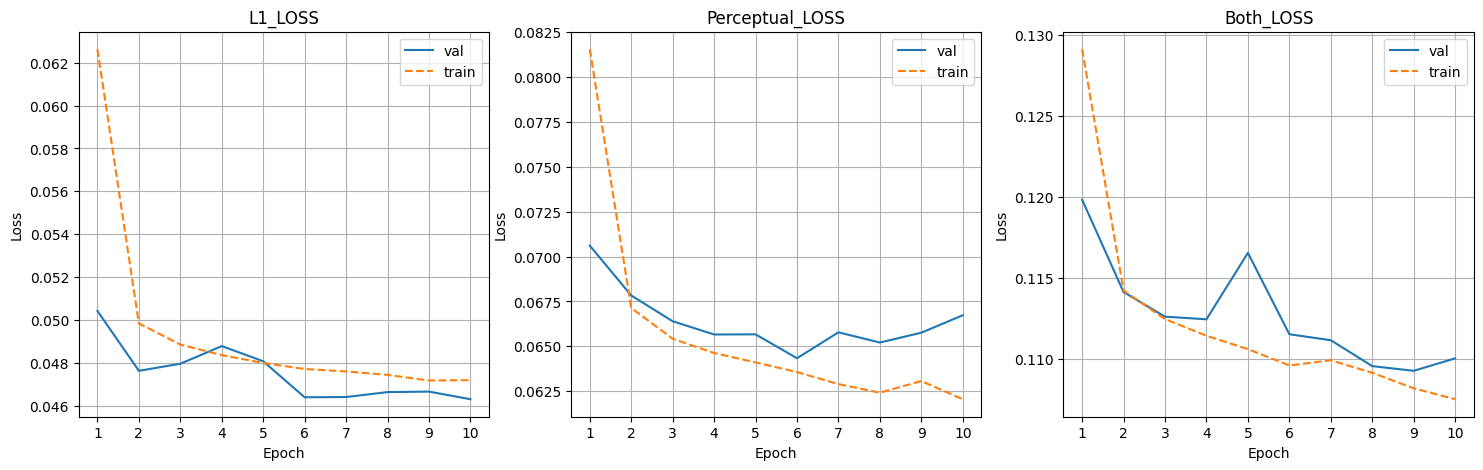

<Figure size 1000x600 with 0 Axes>

In [53]:
df = plot_losses_and_best_table(["L1_LOSS","Perceptual_LOSS","Both_LOSS"],[train_losses_L1,train_losses_prc,train_losses_both],[val_losses_L1,val_losses_prc,val_losses_both],[test_loss_L1,test_loss_prc,test_loss_both],[test_psnr_L1,test_psnr_prc,test_psnr_both],[test_mse_L1,test_mse_prc,test_mse_both],[test_ssim_L1,test_ssim_prc,test_ssim_both])

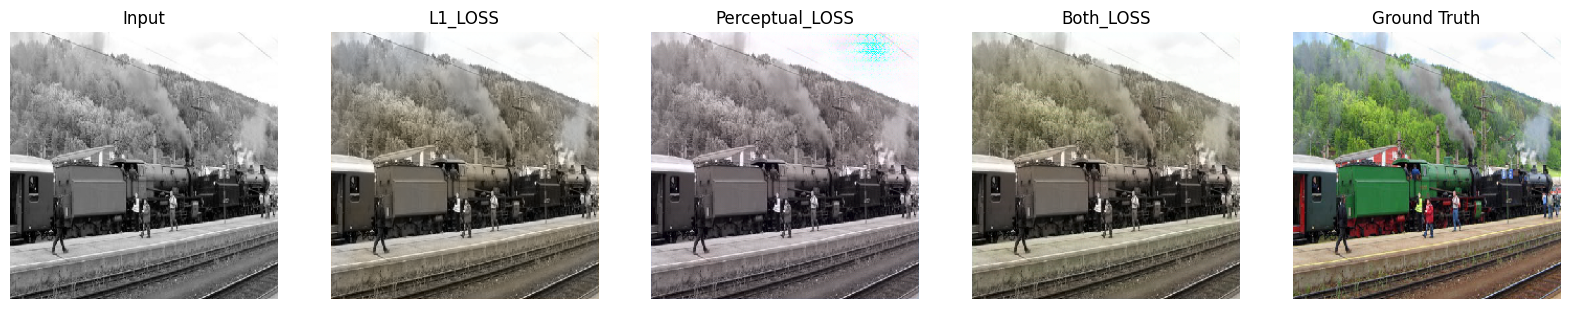

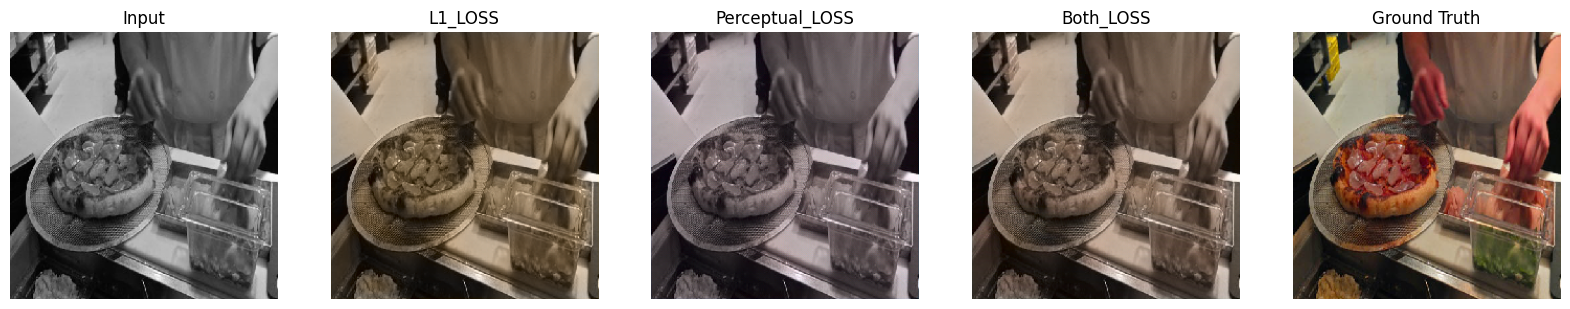

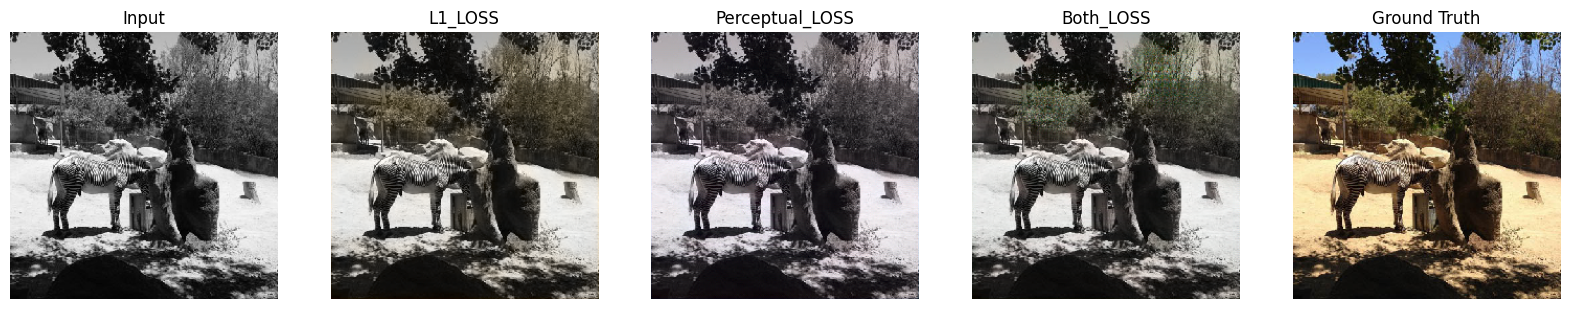

In [56]:
visualize_predictions(data,[5001,5002,5003],pred_lists=[L1_preds,prc_preds,both_preds],model_names=["L1_LOSS","Perceptual_LOSS","Both_LOSS"],device=device)

In [57]:
model = Baseline_Model()
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="L1",
        save_path ="/content/BASE_BEST.pth"
        )
train_losses_base,val_losses_base = tr.fit(30)
model.load_state_dict(torch.load("/content/BASE_BEST.pth", map_location=device))
test_loss_base,test_mse_base,test_psnr_base,test_ssim_base = tr.test()
base_preds = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/30 | LOSS -> Train Loss: 0.0659 : Val Loss: 0.0506 | Metrics -> MSE: 0.0082 : PSNR: 26.88 : SSIM: 0.9248
model is saving

Epoch 2/30 | LOSS -> Train Loss: 0.0500 : Val Loss: 0.0477 | Metrics -> MSE: 0.0076 : PSNR: 27.22 : SSIM: 0.9382
model is saving

Epoch 3/30 | LOSS -> Train Loss: 0.0490 : Val Loss: 0.0488 | Metrics -> MSE: 0.0077 : PSNR: 27.17 : SSIM: 0.9347

Epoch 4/30 | LOSS -> Train Loss: 0.0484 : Val Loss: 0.0478 | Metrics -> MSE: 0.0075 : PSNR: 27.29 : SSIM: 0.9379
model is saving

Epoch 5/30 | LOSS -> Train Loss: 0.0481 : Val Loss: 0.0473 | Metrics -> MSE: 0.0073 : PSNR: 27.36 : SSIM: 0.9395
model is saving

Epoch 6/30 | LOSS -> Train Loss: 0.0479 : Val Loss: 0.0479 | Metrics -> MSE: 0.0075 : PSNR: 27.26 : SSIM: 0.9379

Epoch 7/30 | LOSS -> Train Loss: 0.0477 : Val Loss: 0.0464 | Metrics -> MSE: 0.0070 : PSNR: 27.54 : SSIM: 0.9417
model is saving

Epoch 8/30 | LOSS -> Train Loss: 0.0474 : Val Loss: 0.0464 | Metrics -> MSE: 0.0070 : PSNR: 27.56 : SSIM: 0.9407
model is

In [60]:
torch.cuda.empty_cache()
del model
del tr

In [61]:
model = Baseline_Model(global_f="efficientnet_b0",freeze=True)
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="L1",
        save_path ="/content/GLOBAL_BEST.pth"
        )
train_losses_global,val_losses_global = tr.fit(30)
model.load_state_dict(torch.load("/content/GLOBAL_BEST.pth", map_location=device))
test_loss_global,test_mse_global,test_psnr_global,test_ssim_global = tr.test()
global_preds = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/30 | LOSS -> Train Loss: 0.0730 : Val Loss: 0.0524 | Metrics -> MSE: 0.0092 : PSNR: 26.40 : SSIM: 0.9189
model is saving

Epoch 2/30 | LOSS -> Train Loss: 0.0502 : Val Loss: 0.0479 | Metrics -> MSE: 0.0075 : PSNR: 27.28 : SSIM: 0.9314
model is saving

Epoch 3/30 | LOSS -> Train Loss: 0.0485 : Val Loss: 0.0474 | Metrics -> MSE: 0.0073 : PSNR: 27.42 : SSIM: 0.9341
model is saving

Epoch 4/30 | LOSS -> Train Loss: 0.0475 : Val Loss: 0.0473 | Metrics -> MSE: 0.0072 : PSNR: 27.45 : SSIM: 0.9343
model is saving

Epoch 5/30 | LOSS -> Train Loss: 0.0473 : Val Loss: 0.0467 | Metrics -> MSE: 0.0070 : PSNR: 27.55 : SSIM: 0.9379
model is saving

Epoch 6/30 | LOSS -> Train Loss: 0.0466 : Val Loss: 0.0466 | Metrics -> MSE: 0.0069 : PSNR: 27.64 : SSIM: 0.9383
model is saving

Epoch 7/30 | LOSS -> Train Loss: 0.0463 : Val Loss: 0.0457 | Metrics -> MSE: 0.0068 : PSNR: 27.69 : SSIM: 0.9399
model is saving

Epoch 8/30 | LOSS -> Train Loss: 0.0461 : Val Loss: 0.0468 | Metrics -> MSE: 0.0071 : PSN

In [62]:
torch.cuda.empty_cache()
del model
del tr

In [65]:
model = U_net_based_model(global_f="efficientnet_b0",freeze=True)
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="L1",
        save_path ="/content/UNET_BEST.pth"
        )
train_losses_U_net,val_losses_U_net = tr.fit(30)
model.load_state_dict(torch.load("/content/UNET_BEST.pth", map_location=device))
test_loss_U_net,test_mse_U_net,test_psnr_U_net,test_ssim_U_net = tr.test()
U_net_preds = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/30 | LOSS -> Train Loss: 0.0841 : Val Loss: 0.0666 | Metrics -> MSE: 0.0104 : PSNR: 25.85 : SSIM: 0.8824
model is saving

Epoch 2/30 | LOSS -> Train Loss: 0.0528 : Val Loss: 0.0507 | Metrics -> MSE: 0.0078 : PSNR: 27.12 : SSIM: 0.9197
model is saving

Epoch 3/30 | LOSS -> Train Loss: 0.0494 : Val Loss: 0.0535 | Metrics -> MSE: 0.0088 : PSNR: 26.56 : SSIM: 0.9118

Epoch 4/30 | LOSS -> Train Loss: 0.0483 : Val Loss: 0.0469 | Metrics -> MSE: 0.0069 : PSNR: 27.60 : SSIM: 0.9323
model is saving

Epoch 5/30 | LOSS -> Train Loss: 0.0474 : Val Loss: 0.0469 | Metrics -> MSE: 0.0070 : PSNR: 27.54 : SSIM: 0.9337

Epoch 6/30 | LOSS -> Train Loss: 0.0468 : Val Loss: 0.0474 | Metrics -> MSE: 0.0071 : PSNR: 27.49 : SSIM: 0.9275

Epoch 7/30 | LOSS -> Train Loss: 0.0465 : Val Loss: 0.0472 | Metrics -> MSE: 0.0073 : PSNR: 27.40 : SSIM: 0.9352

Epoch 8/30 | LOSS -> Train Loss: 0.0461 : Val Loss: 0.0466 | Metrics -> MSE: 0.0069 : PSNR: 27.63 : SSIM: 0.9343
model is saving

Epoch 9/30 | LOSS -> Tr

In [66]:
torch.cuda.empty_cache()
del model
del tr

In [67]:
model = U_net_based_model(global_f="efficientnet_b0",freeze=False)
tr=Trainer(device = device,
        model = model,
        optimizer = torch.optim.Adam(model.parameters(),lr=4e-5,weight_decay=1e-4),
        data = data,
        loss="L1",
        save_path ="/content/UNET_BEST_fine.pth"
        )
train_losses_U_net_fine,val_losses_U_net_fine = tr.fit(30)
model.load_state_dict(torch.load("/content/UNET_BEST_fine.pth", map_location=device))
test_loss_U_net_fine,test_mse_U_net_fine,test_psnr_U_net_fine,test_ssim_U_net_fine = tr.test()
U_net_preds_fine = run_model_on_three_samples(model,data,[5001,5002,5003],device)


Epoch 1/30 | LOSS -> Train Loss: 0.0818 : Val Loss: 0.0620 | Metrics -> MSE: 0.0095 : PSNR: 26.24 : SSIM: 0.9086
model is saving

Epoch 2/30 | LOSS -> Train Loss: 0.0514 : Val Loss: 0.0512 | Metrics -> MSE: 0.0079 : PSNR: 27.04 : SSIM: 0.9251
model is saving

Epoch 3/30 | LOSS -> Train Loss: 0.0484 : Val Loss: 0.0500 | Metrics -> MSE: 0.0077 : PSNR: 27.15 : SSIM: 0.9275
model is saving

Epoch 4/30 | LOSS -> Train Loss: 0.0470 : Val Loss: 0.0470 | Metrics -> MSE: 0.0070 : PSNR: 27.56 : SSIM: 0.9350
model is saving

Epoch 5/30 | LOSS -> Train Loss: 0.0457 : Val Loss: 0.0473 | Metrics -> MSE: 0.0070 : PSNR: 27.60 : SSIM: 0.9346
model is saving

Epoch 6/30 | LOSS -> Train Loss: 0.0446 : Val Loss: 0.0470 | Metrics -> MSE: 0.0069 : PSNR: 27.64 : SSIM: 0.9357
model is saving

Epoch 7/30 | LOSS -> Train Loss: 0.0441 : Val Loss: 0.0460 | Metrics -> MSE: 0.0067 : PSNR: 27.73 : SSIM: 0.9386
model is saving

Epoch 8/30 | LOSS -> Train Loss: 0.0434 : Val Loss: 0.0460 | Metrics -> MSE: 0.0067 : PSN

Following the loss function experiments, a comprehensive comparison is conducted across four distinct model configurations: the Base Model, the Base Model with a frozen EfficientNet backbone, the U-Net architecture with a frozen EfficientNet, and the U-Net with an unfrozen (fine-tuned) EfficientNet. When the results of the Base Model and the frozen EfficientNet variant are analyzed, a similar level of performance is observed. This similarity is attributed to the compact nature of the EfficientNet architecture, which is designed with fewer parameters to prioritize speed, and the fact that the backbone weights were not fine-tuned to the specific domain of the dataset.

A noticeable improvement is recorded when the U-Net architecture is adopted. Superior results are produced by the U-Net models compared to both the Base Model and the standard EfficientNet implementation. It is acknowledged that the skip connections within the U-Net structure helped to mitigate the vanishing gradient problem to a certain extent; however, it is indicated that the vanishing gradient was not the primary limitation, a topic which will be addressed in the subsequent section. Among all tested configurations, the most outstanding performance is demonstrated by the U-Net model with the fine-tuned EfficientNet backbone. A validation PSNR score of 28 is achieved, and the most realistic and vibrant colorization outputs are generated by this specific model. Despite these successes, when the visual samples are examined, it is noted that the first image serves as a failure case for the majority of the models, as consistent colorization could not be fully recovered in that specific instance.

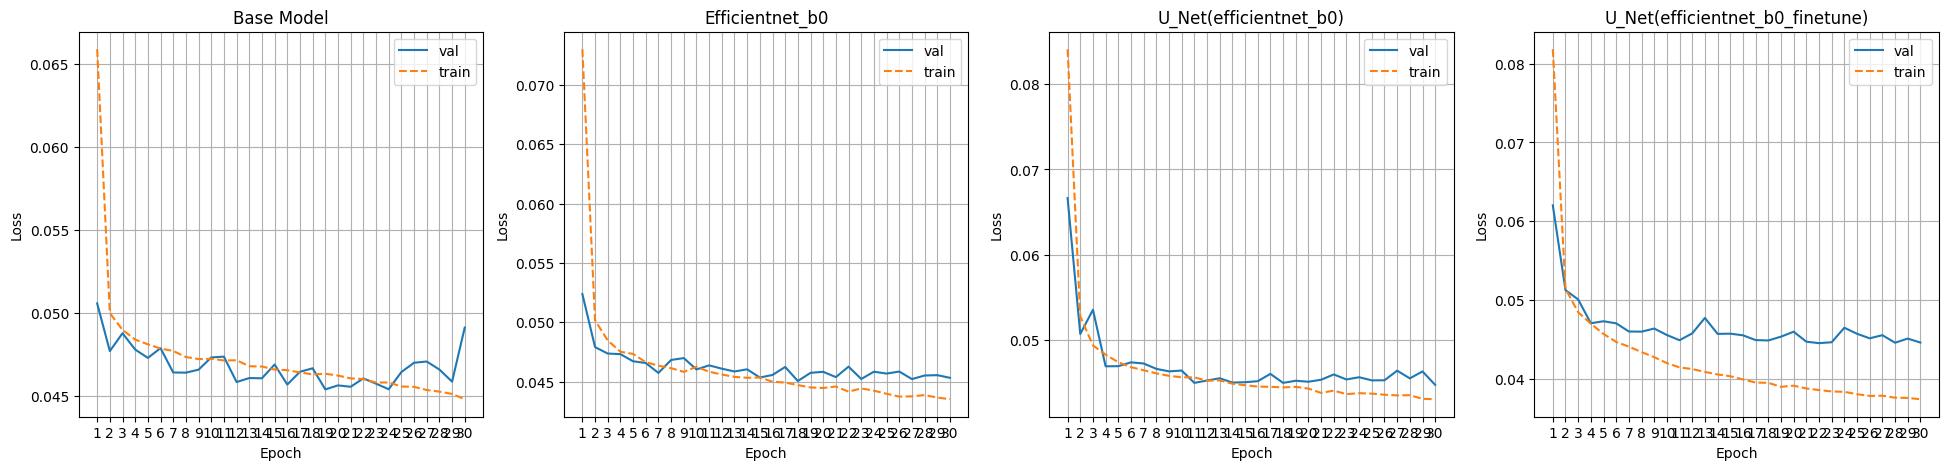

<Figure size 1000x600 with 0 Axes>

In [68]:
df2 = plot_losses_and_best_table(["Base Model","Efficientnet_b0","U_Net(efficientnet_b0)","U_Net(efficientnet_b0_finetune)"],[train_losses_base,train_losses_global,train_losses_U_net,train_losses_U_net_fine],[val_losses_base,val_losses_global,val_losses_U_net,val_losses_U_net_fine],[test_loss_base,test_loss_global,test_loss_U_net,test_loss_U_net_fine],[test_psnr_base,test_psnr_global,test_psnr_U_net,test_psnr_U_net_fine],[test_mse_base,test_mse_global,test_mse_U_net,test_mse_U_net_fine],[test_ssim_base,test_ssim_global,test_ssim_U_net,test_ssim_U_net_fine])

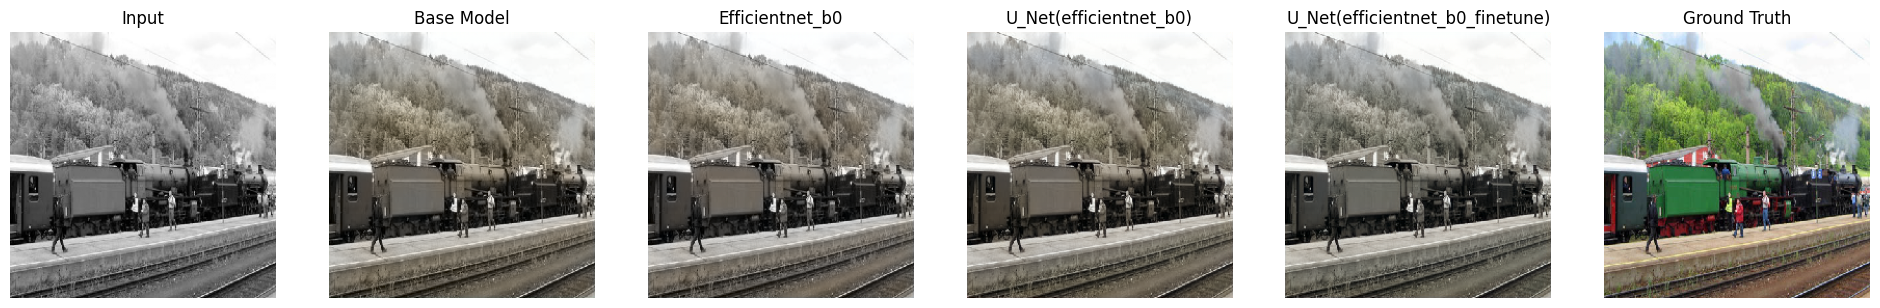

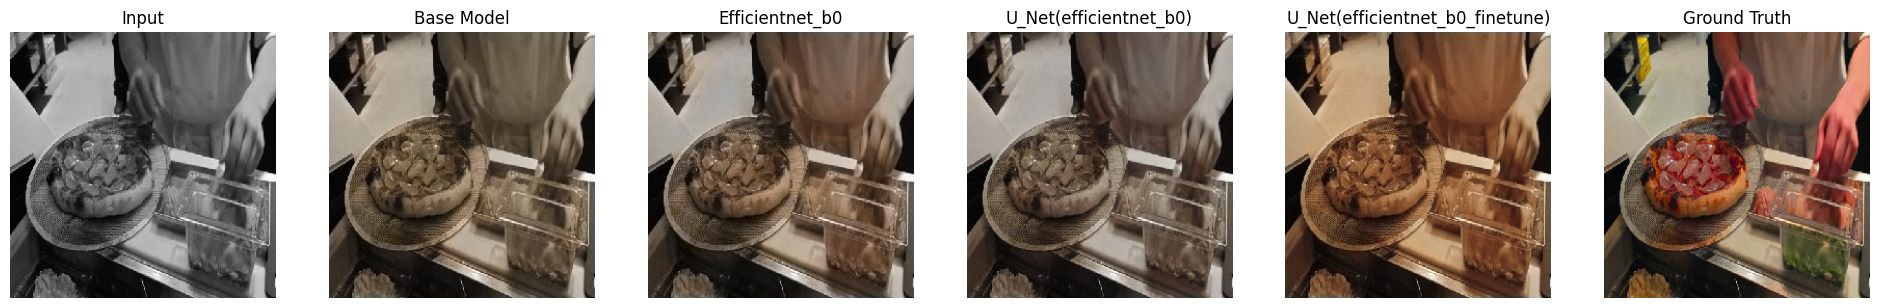

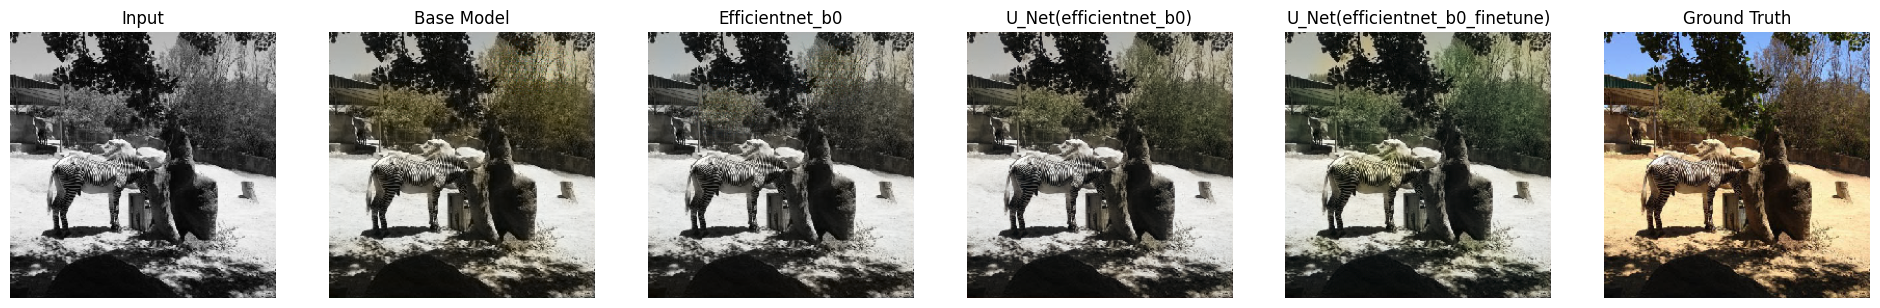

In [71]:
visualize_predictions(data,[5001,5002,5003],pred_lists=[base_preds,global_preds,U_net_preds,U_net_preds_fine],model_names=["Base Model","Efficientnet_b0","U_Net(efficientnet_b0)","U_Net(efficientnet_b0_finetune)"],device=device)

The remarkable similarity observed in the quantitative results across the different configurations is primarily attributed to the substantial capacity of the baseline architecture provided in the assignment. It is noted that the encoder and decoder components alone contain over 7 million parameters. When such a high-capacity model is trained on the relatively small custom dataset of 5000 images, a performance ceiling is reached very rapidly. This rapid saturation acts as a restrictive constraint, creating a scenario that borders on overfitting, where the model's potential is limited by the available data rather than its architectural depth. Although larger models exceeding 30 million parameters were experimentally tested during the study, it was determined that increasing the complexity further did not resolve the issue. Instead, the primary bottlenecks were identified as this data-induced constraint combined with the vanishing gradient problem inherent in deeper networks. Despite these systemic limitations, the U-Net architecture with the fine-tuned EfficientNet backbone is distinguished as the most effective solution, as it successfully mitigated some of these challenges to deliver the highest validation scores and the most visually accurate colorizations.

In [76]:
cols = [ "ssim", "psnr", "mse","val_loss_at_best"]  # istediğin kolon adları

df.columns = cols
df2.columns = cols

pd.concat([df, df2], axis=0, ignore_index=False)

,ssim,psnr,mse,val_loss_at_best
model,,,,
L1_LOSS,0.942412,27.621109,0.006917,0.046615
Perceptual_LOSS,0.924984,26.182749,0.009634,0.060469
Both_LOSS,0.941175,27.602503,0.006947,0.105571
Base Model,0.943894,27.731512,0.006744,0.045224
Efficientnet_b0,0.943745,27.931690,0.006440,0.044835
U_Net(efficientnet_b0),0.941083,27.794800,0.006646,0.045464
U_Net(efficientnet_b0_finetune),0.944748,27.950600,0.006412,0.044438


**8. Discussion**


In the final evaluation of the project, the U-Net architecture equipped with the fine-tuned EfficientNet B0 backbone is identified as the version that performed best among all tested configurations. It is observed that the integration of a pretrained global feature extractor played a crucial role in capturing the semantic context of the images, which led to more realistic color predictions compared to the baseline models. Although it is acknowledged that heavier and deeper architectures, such as ResNet50, could potentially offer superior feature extraction capabilities, they were not selected for this study. This decision was primarily driven by the need to maintain reasonable training times and computational efficiency, as the EfficientNet B0 was found to offer an optimal balance between performance and speed.

Regarding the computational cost and training duration,  the training time for a single epoch ranged approximately between 30 and 45 seconds across the four different model variations. This efficiency was maintained largely due to the relatively low parameter count of the selected backbone. While the combined loss function (L1 + Perceptual) was determined to produce the highest visual quality, the L1 loss was utilized for the majority of the architectural comparisons because stable convergence was achieved more rapidly.

**9. Failure Cases and Short Discussion**


In the analysis of the generated outputs, specific failure cases were identified where the model was unable to correctly reconstruct the color information. These shortcomings are largely attributed to the phenomenon of performance saturation discussed in the previous sections. It is observed that the capacity of the model, which contains millions of parameters, significantly exceeds the diversity found in the limited dataset of 5000 images. Consequently, a "squeezing" effect occurred during the optimization process, where the gradients diminished rapidly once a basic level of accuracy was achieved. Because the model was constrained by this data ceiling, it was unable to learn the fine-grained features required for highly complex or ambiguous scenes. This issue resulted in grayish or muted colors in certain test images, as the network opted for a safe, average prediction rather than risking a vibrant but potentially incorrect color choice.

**10. Short Summary and Suggestions for Improvement**


In this final section, the overall project outcomes are summarized. Despite the limitations related to the dataset size and the gradient saturation issues highlighted in the failure cases, it is concluded that a successful performance was achieved by the U-Net model with the fine-tuned EfficientNet backbone. The effectiveness of this specific architecture was confirmed by the visually coherent and vibrant results obtained in the test set, proving that the model could handle the colorization task effectively even under constraints.

To further improve the system in future iterations, specific modifications are suggested. It is proposed that the capacity of the base model be reduced to better align with smaller datasets, which would help prevent early performance saturation. Simultaneously, the influence of the global feature extractor could be amplified to ensure that the semantic context guides the colorization process more dominantly. Furthermore, additional skip connections could be inserted between the layers to facilitate a stronger flow of spatial information. Finally, the integration of a PatchGAN discriminator is recommended, as this adversarial approach would likely enforce higher realism and texture consistency in the generated images.